# Credit Card Default Prediction

**Business question:** which credit card customers are most likely to miss next month's payment, so the bank can focus collections calls, payment-plan offers and credit-limit reviews on them?

This notebook takes 24,000 credit card accounts from a Taiwanese bank. It cleans and explores the data, then compares four models and turns the best one into a simple decision rule a credit team could use.

**Contents**
1. Data and quality checks
2. What drives default (EDA)
3. Feature preparation
4. Model comparison
5. Turning scores into decisions
6. What drives the model's predictions
7. Recommendations and limitations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 777

# Chart style: light surface, recessive grid, one accent colour
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

## 1. Data and quality checks

The data is the *Default of Credit Card Clients* dataset (Yeh & Lien, 2009, UCI Machine Learning Repository). This copy holds 24,000 of the original 30,000 accounts. Each row covers one customer from April to September 2005:

| Group | Columns | Meaning |
|---|---|---|
| Account | `LIMIT_BAL` | Credit limit (NT$) |
| Demographics | `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` | Coded categories, age in years |
| Repayment status | `PAY_1` … `PAY_6` | Months late each month (`PAY_1` = September, most recent). −2/−1/0 = no delay |
| Bill amounts | `BILL_AMT1` … `BILL_AMT6` | Statement balance each month |
| Payments | `PAY_AMT1` … `PAY_AMT6` | Amount paid each month |
| **Target** | `default` | 1 = defaulted on the next payment (October) |

In [2]:
df = pd.read_csv("credit_card_default.csv").rename(columns={"default": "payment_default"})
print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print(f"Default rate: {df['payment_default'].mean():.1%}")
df.head()

Shape: (24000, 24)
Missing values: 0
Duplicate rows: 24
Default rate: 22.1%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,payment_default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,90000,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
2,50000,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
3,50000,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
4,50000,1,1,2,37,0,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0


In [3]:
print("EDUCATION:", df["EDUCATION"].value_counts().sort_index().to_dict())
print("MARRIAGE: ", df["MARRIAGE"].value_counts().sort_index().to_dict())

EDUCATION: {0: 11, 1: 8486, 2: 11213, 3: 3944, 4: 90, 5: 217, 6: 39}
MARRIAGE:  {0: 42, 1: 10897, 2: 12808, 3: 253}


**Data quality findings**

- There are no missing values. The handful of duplicate rows are plausible separate customers with identical histories, so I keep them.
- `EDUCATION` is documented as 1 = graduate school, 2 = university, 3 = high school, 4 = other, but the data also contains 0, 5 and 6. These undocumented codes cover under 1.5% of rows, so I fold them into 4 ("other").
- `MARRIAGE` is documented as 1 = married, 2 = single, 3 = other, but 42 rows contain 0. I fold these into 3 ("other").
- About 22% of customers default. Because the classes are imbalanced, **accuracy alone is misleading**: a model that predicts "no default" for everyone is already about 78% accurate.

In [4]:
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
print("EDUCATION:", df["EDUCATION"].value_counts().sort_index().to_dict())
print("MARRIAGE: ", df["MARRIAGE"].value_counts().sort_index().to_dict())

EDUCATION: {1: 8486, 2: 11213, 3: 3944, 4: 357}
MARRIAGE:  {1: 10897, 2: 12808, 3: 295}


## 2. What drives default?

Start with the variable a credit analyst would check first: how late the customer was on their most recent payment.

,default rate %,customers
No use,13.0,2207
Paid in full,17.1,4636
Revolving,12.8,11765
1 month late,33.8,2907
2 months late,69.6,2127
3+ months late,71.2,358


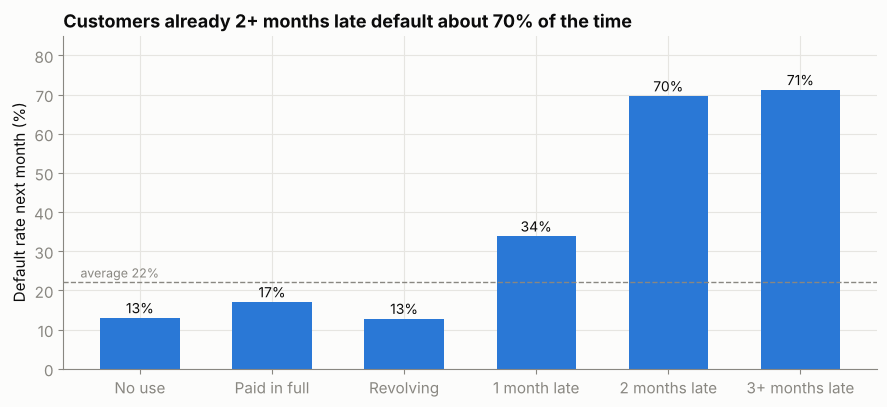

In [5]:
status = df["PAY_1"].clip(upper=3)  # group 3+ months late (small groups)
labels = {-2: "No use", -1: "Paid in full", 0: "Revolving", 1: "1 month late", 2: "2 months late", 3: "3+ months late"}
rate_by_status = df.groupby(status)["payment_default"].agg(rate="mean", customers="size")
rate_by_status.index = [labels[i] for i in rate_by_status.index]
display(rate_by_status.assign(rate=lambda t: (t["rate"] * 100).round(1)).rename(columns={"rate": "default rate %"}))

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(rate_by_status.index, rate_by_status["rate"] * 100, color=BLUE, width=0.6)
for b, v in zip(bars, rate_by_status["rate"] * 100):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.0f}%", ha="center", color=INK, fontsize=10)
ax.axhline(df["payment_default"].mean() * 100, color=MUTED, linestyle="--", linewidth=1)
ax.text(-0.45, df["payment_default"].mean() * 100 + 1.2, "average 22%", color=MUTED, fontsize=9, ha="left")
ax.set_ylabel("Default rate next month (%)")
ax.set_ylim(0, 85)
ax.set_title("Customers already 2+ months late default about 70% of the time")
plt.tight_layout(); plt.savefig("default_by_status.png", dpi=150); plt.show()

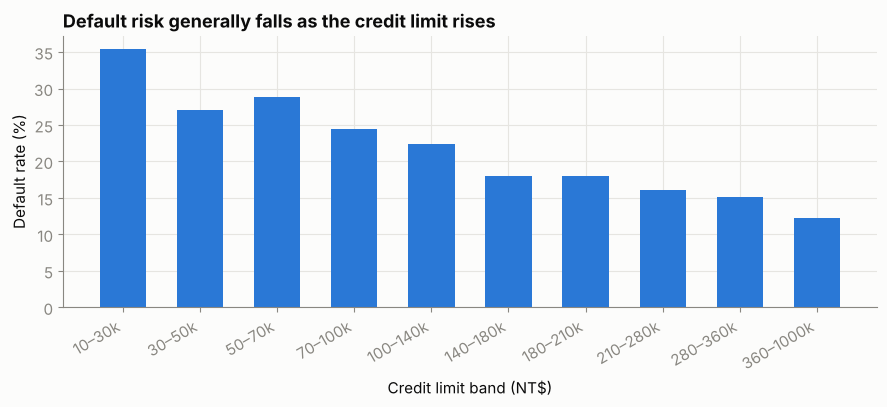

LIMIT_BAL
(9999.999, 30000.0]      35.4
(30000.0, 50000.0]       27.0
(50000.0, 70000.0]       28.8
(70000.0, 100000.0]      24.4
(100000.0, 140000.0]     22.3
(140000.0, 180000.0]     18.0
(180000.0, 210000.0]     18.0
(210000.0, 280000.0]     16.1
(280000.0, 360000.0]     15.1
(360000.0, 1000000.0]    12.2


In [6]:
deciles = pd.qcut(df["LIMIT_BAL"], 10, duplicates="drop")
rate_by_limit = df.groupby(deciles, observed=True)["payment_default"].mean() * 100
tick_labels = [f"{round(iv.left/1000)}–{round(iv.right/1000)}k" for iv in rate_by_limit.index]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(range(len(rate_by_limit)), rate_by_limit.values, color=BLUE, width=0.6)
ax.set_xticks(range(len(rate_by_limit)), tick_labels, rotation=30, ha="right")
ax.set_xlabel("Credit limit band (NT$)")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default risk generally falls as the credit limit rises")
plt.tight_layout(); plt.savefig("default_by_limit.png", dpi=150); plt.show()
print(rate_by_limit.round(1).to_string())

**Takeaways**

- **Recent repayment behaviour dominates.** Customers 2+ months behind on the latest statement default about 70% of the time, more than three times the 22% average.
- **Lower credit limits mean higher risk.** About 35% of customers in the lowest limit band default, against 12% in the highest. The bank has already partly priced risk into the limits it sets.
- Customers who paid in full or revolved normally sit well below the 22% average.

## 3. Feature preparation

I add three features that a credit analyst would naturally look at:

- `utilisation` is the latest bill divided by the credit limit, i.e. how maxed-out the card is.
- `payment_ratio` is the latest payment divided by the previous bill, capped at 1, i.e. how much of the balance gets paid off.
- `months_late` is the number of the six months in which the customer was behind.

I **exclude `SEX`** from the model. Using gender in a credit decision is a fairness and regulatory risk.

In [7]:
df["utilisation"] = (df["BILL_AMT1"] / df["LIMIT_BAL"]).clip(-1, 2)
df["payment_ratio"] = np.where(df["BILL_AMT2"] > 0, df["PAY_AMT1"] / df["BILL_AMT2"], 1).clip(0, 1)
df["months_late"] = (df[[f"PAY_{i}" for i in range(1, 7)]] > 0).sum(axis=1)

categorical = ["EDUCATION", "MARRIAGE"]
numeric = [c for c in df.columns if c not in categorical + ["SEX", "payment_default"]]

X = df[categorical + numeric]
y = df["payment_default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", StandardScaler(), numeric),
])
print("Train:", X_train.shape, " Test:", X_test.shape)
print(f"Default rate - train {y_train.mean():.1%}, test {y_test.mean():.1%}")

Train: (16800, 25)  Test: (7200, 25)
Default rate - train 22.1%, test 22.1%


## 4. Model comparison

I compare models of increasing complexity. Every model sits inside a pipeline, so the scaling and encoding are learned on the training set only, which avoids leakage.

- **Baseline** always predicts "no default". Any real model has to beat this.
- **Logistic regression** is linear and interpretable. `class_weight="balanced"` makes it care about the minority class.
- **Decision tree (unconstrained)** shows what overfitting looks like.
- **Decision tree (tuned)** gets its depth chosen by 5-fold cross-validation.
- **Random forest** averages many trees, which usually generalises better.

Because the classes are imbalanced, I judge the models on **ROC-AUC** (how well they rank risky customers above safe ones) and **recall** (the share of actual defaulters they catch), as well as accuracy.

In [8]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

tuned_tree = GridSearchCV(
    Pipeline([("prep", preprocess), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))]),
    {"clf__max_depth": [3, 4, 5, 6, 8], "clf__min_samples_leaf": [20, 50, 100]},
    scoring="roc_auc", cv=cv, n_jobs=-1)

models = {
    "Baseline (always 'no default')": Pipeline([("prep", preprocess), ("clf", DummyClassifier(strategy="most_frequent"))]),
    "Logistic regression": Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Decision tree (unconstrained)": Pipeline([("prep", preprocess), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    "Decision tree (tuned)": tuned_tree,
    "Random forest": Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(
        n_estimators=400, min_samples_leaf=20, class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE))]),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Train accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
print("Tuned tree parameters:", tuned_tree.best_params_)
results

Tuned tree parameters: {'clf__max_depth': 6, 'clf__min_samples_leaf': 100}


,Train accuracy,Test accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Baseline (always 'no default'),0.779,0.779,0.000,0.000,0.000,0.500
Logistic regression,0.767,0.771,0.486,0.583,0.530,0.758
Decision tree (unconstrained),0.999,0.721,0.381,0.415,0.397,0.612
Decision tree (tuned),0.738,0.725,0.420,0.647,0.510,0.770
Random forest,0.818,0.781,0.504,0.606,0.550,0.786


**Reading the table**

- **Accuracy is a trap here.** The baseline scores about 78% while catching zero defaulters.
- **The unconstrained tree overfits.** It is perfect on training data but the weakest real model on test data, because it memorised the training set instead of learning general patterns.
- **The balanced models trade some accuracy for much higher recall.** For a bank, missing a defaulter usually costs far more than an extra review call, so this trade is worth making.
- **The random forest ranks risk best** (highest ROC-AUC), so I take it forward.

## 5. Turning scores into decisions

A credit team doesn't act on a probability. It acts on a list. The practical question is: **if we review the riskiest X% of customers, what share of next month's defaulters do we reach?**

,Customers reviewed,Defaulters reached,Random selection
0,10%,31%,10%
1,20%,51%,20%
2,30%,64%,30%
3,40%,72%,40%


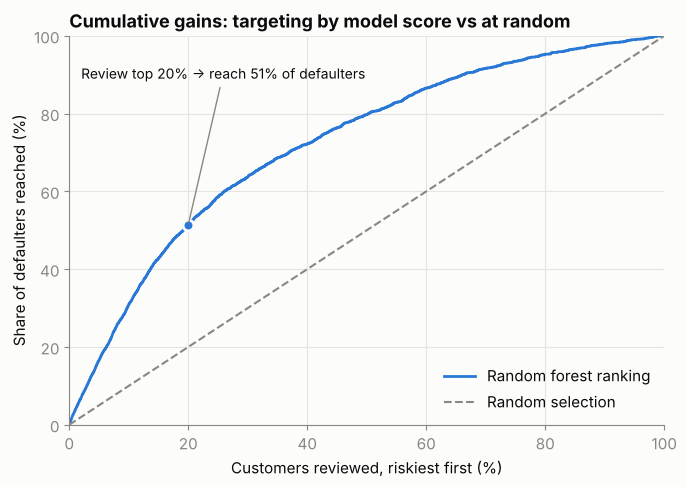

In [9]:
best = models["Random forest"]
scores = best.predict_proba(X_test)[:, 1]
order = np.argsort(-scores)
captured = np.cumsum(y_test.to_numpy()[order]) / y_test.sum()
reviewed = np.arange(1, len(order) + 1) / len(order)

capture_table = pd.DataFrame({
    "Customers reviewed": ["10%", "20%", "30%", "40%"],
    "Defaulters reached": [f"{captured[int(p * len(order)) - 1]:.0%}" for p in (0.1, 0.2, 0.3, 0.4)],
    "Random selection": ["10%", "20%", "30%", "40%"],
})
display(capture_table)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(reviewed * 100, captured * 100, color=BLUE, linewidth=2, label="Random forest ranking")
ax.plot([0, 100], [0, 100], color=MUTED, linewidth=1.5, linestyle="--", label="Random selection")
p20 = captured[int(0.2 * len(order)) - 1] * 100
ax.scatter([20], [p20], s=60, color=BLUE, edgecolor="#fcfcfb", linewidth=2, zorder=3)
ax.annotate(f"Review top 20% → reach {p20:.0f}% of defaulters", (20, p20), xytext=(2, 89),
            fontsize=10, color=INK, ha="left", arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_xlabel("Customers reviewed, riskiest first (%)")
ax.set_ylabel("Share of defaulters reached (%)")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Cumulative gains: targeting by model score vs at random")
plt.tight_layout(); plt.savefig("gains_curve.png", dpi=150); plt.show()

## 6. What drives the model's predictions?

Permutation importance measures how much the test ROC-AUC drops when a single feature is shuffled. It works for any model and it's computed on unseen data.

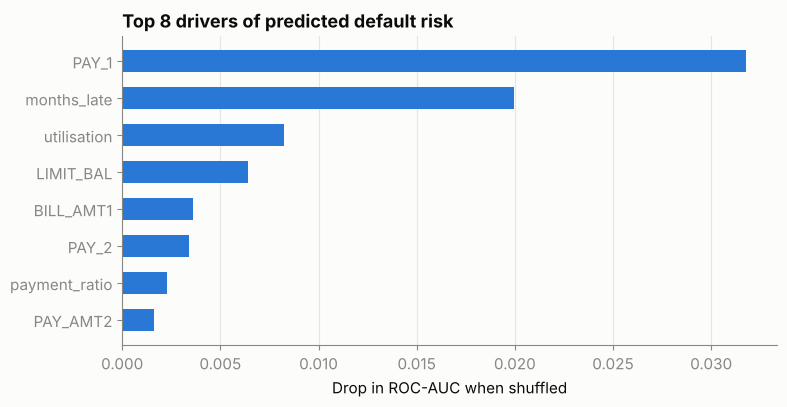

PAY_1            0.0318
months_late      0.0200
utilisation      0.0082
LIMIT_BAL        0.0064
BILL_AMT1        0.0036
PAY_2            0.0034
payment_ratio    0.0023
PAY_AMT2         0.0016
dtype: float64

In [10]:
imp = permutation_importance(best, X_test, y_test, scoring="roc_auc", n_repeats=5,
                             random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(imp.importances_mean, index=X_test.columns).sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(importance.index[::-1], importance.values[::-1], color=BLUE, height=0.6)
ax.set_xlabel("Drop in ROC-AUC when shuffled")
ax.grid(axis="y", visible=False)
ax.set_title("Top 8 drivers of predicted default risk")
plt.tight_layout(); plt.savefig("feature_importance.png", dpi=150); plt.show()
importance.round(4)

## 7. Recommendations and limitations

**Recommendations for a credit team**

1. **Prioritise outreach by model score, not by gut feel.** Reviewing the riskiest 20% of accounts reaches far more defaulters than random or rule-of-thumb selection (see the gains table above).
2. **Treat a missed latest payment as an early-warning trigger.** Recent repayment status is by far the strongest signal. A customer who slips to 1–2 months late should get a payment-plan offer before the debt compounds.
3. **Review limits for low-limit, high-utilisation customers** rather than cutting limits across the board.

**Limitations**

- The data is from one Taiwanese bank in 2005, so the patterns need re-validating on current, local data before use.
- The model predicts one month ahead only, and it has no income or employment data.
- I removed `SEX`, but `AGE` and `MARRIAGE` may still need a fairness review under local lending rules.
- The threshold for action should be set with the business, using the real cost of a missed default against the cost of a review.

---
*Originally built for a Macquarie University Business Analytics assignment, then extended into this portfolio version with a public dataset copy, imbalance-aware metrics, cross-validated tuning, a random forest, a cumulative gains analysis and business recommendations.*